# 01 — Play-Type EDA

Exploratory analysis of `data/interim/pbp_clean.parquet` for the **play-type classification** task: predict run vs. pass from pre-snap situation.

Sections:
1. Data — head, shape, info
2. Target — Run vs. Pass class balance
3. Quantitative Features — distributions + summary statistics
4. Categorical Features — pass rate by category

> Play *outcome* columns (`yards_gained`, `epa`) are not pre-snap observable and are excluded from modeling as leakage — they are not analyzed here as predictors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

RUN_COLOR = "#DD8452"
PASS_COLOR = "#4C72B0"

ROOT = Path("..").resolve()
pbp = pd.read_parquet(ROOT / "data/interim/pbp_clean.parquet")

# Restrict to the two modeled classes; add a binary pass indicator.
pbp = pbp[pbp["play_type"].isin(["run", "pass"])].copy()
pbp["is_pass"] = (pbp["play_type"] == "pass").astype(int)

print(f"Shape:   {pbp.shape}")
print(f"Seasons: {sorted(pbp['season'].unique())}")

Shape:   (276286, 33)
Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Data — Head, Shape, Info

In [2]:
pbp.head()

,game_id,play_id,season,week,game_date,season_type,home_team,away_team,posteam,defteam,posteam_type,game_half,qtr,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,down,ydstogo,yardline_100,posteam_score,defteam_score,play_type,offense_formation,defenders_in_box,offense_personnel,defense_personnel,roof,surface,temp,wind,epa,yards_gained,is_pass
0,2024_01_ARI_BUF,61.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,900.000,1800.000,3600.000,1,10,70.000,0,0,run,UNDER CENTER,7,"2 C, 1 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,-0.201,3.000,0
1,2024_01_ARI_BUF,83.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,867.000,1767.000,3567.000,2,7,67.000,0,0,pass,UNDER CENTER,6,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,2.029,22.000,1
2,2024_01_ARI_BUF,108.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,823.000,1723.000,3523.000,1,10,45.000,0,0,pass,SHOTGUN,6,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,0.754,9.000,1
3,2024_01_ARI_BUF,133.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,782.000,1682.000,3482.000,2,1,36.000,0,0,run,UNDER CENTER,8,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,-0.030,2.000,0
4,2024_01_ARI_BUF,155.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,746.000,1646.000,3446.000,1,10,34.000,0,0,run,PISTOL,7,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,-0.248,2.000,0


In [3]:
# Printing data shape
print(f"Rows: {pbp.shape[0]:,}")
print(f"Columns: {pbp.shape[1]}")

Rows: 276,286
Columns: 33


In [4]:
# Column names, non-null counts, dtypes
pbp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 276286 entries, 0 to 276285
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   game_id                    276286 non-null  object 
 1   play_id                    276286 non-null  float32
 2   season                     276286 non-null  int64  
 3   week                       276286 non-null  Int64  
 4   game_date                  276286 non-null  object 
 5   season_type                276286 non-null  object 
 6   home_team                  276286 non-null  object 
 7   away_team                  276286 non-null  object 
 8   posteam                    276286 non-null  object 
 9   defteam                    276286 non-null  object 
 10  posteam_type               276286 non-null  object 
 11  game_half                  276286 non-null  object 
 12  qtr                        276286 non-null  Int64  
 13  quarter_seconds_remaining  27

In [5]:
# Missingness by column (only columns with nulls)
nulls = pbp.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
(
    nulls.to_frame("null_count")
    .assign(null_pct=lambda d: (d["null_count"] / len(pbp) * 100).round(2))
)

,null_count,null_pct
offense_formation,772,0.280
epa,1,0.000


## 2. Target — Run vs. Pass Class Balance

`play_type` (run/pass) is the classification target. Check the split before modeling.

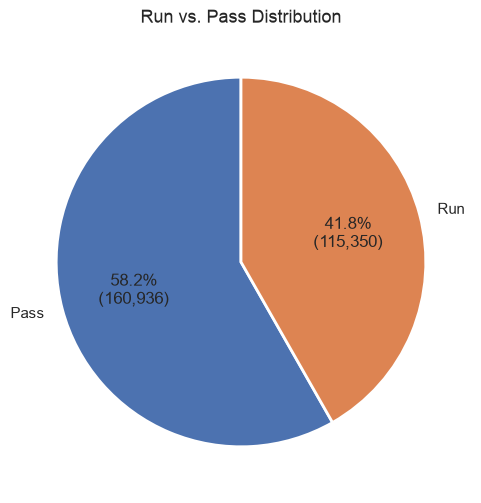

Total plays: 276,286


,count,proportion
pass,160936,0.582
run,115350,0.418


In [6]:
target_counts = pbp["play_type"].value_counts()
pass_rate = pbp["is_pass"].mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    target_counts,
    labels=[idx.capitalize() for idx in target_counts.index],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * len(pbp) / 100)):,})",
    startangle=90,
    colors=[PASS_COLOR if idx == "pass" else RUN_COLOR for idx in target_counts.index],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title(f"Run vs. Pass Distribution", fontsize=13)
plt.show()

print(f"Total plays: {len(pbp):,}")
(
    target_counts.to_frame("count")
    .assign(proportion=lambda d: d["count"] / d["count"].sum())
)

Classes are close to balanced (pass rate ~57%), so no resampling is needed and `roc_auc` is a fair headline metric.

## 3. Quantitative Features — Distributions + Summary Statistics

In [7]:
# Pre-snap numeric features (outcome columns yards_gained / epa excluded as leakage)
num_cols = [
    "quarter_seconds_remaining",
    "half_seconds_remaining",
    "game_seconds_remaining",
    "ydstogo",
    "yardline_100",
    "posteam_score",
    "defteam_score",
    "defenders_in_box",
    "temp",
    "wind",
]

In [8]:
# Summary statistics
pbp[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
quarter_seconds_remaining,276286.000,431.986,270.575,0.000,186.000,421.000,667.000,900.000
half_seconds_remaining,276286.000,841.453,543.302,0.000,344.000,827.000,1313.000,1800.000
game_seconds_remaining,276286.000,1735.062,1046.688,0.000,819.250,1800.000,2622.000,3600.000
ydstogo,276286.000,8.485,3.966,1.000,6.000,10.000,10.000,43.000
yardline_100,276286.000,50.546,24.199,1.000,32.000,54.000,70.000,99.000
posteam_score,276286.000,10.262,9.369,0.000,3.000,7.000,17.000,70.000
defteam_score,276286.000,11.878,10.145,0.000,3.000,10.000,18.000,70.000
defenders_in_box,276286.000,6.288,1.044,0.000,6.000,6.000,7.000,11.000
temp,276286.000,35.706,30.932,-4.000,0.000,41.000,62.000,97.000
wind,276286.000,5.163,5.581,0.000,0.000,4.000,9.000,44.000


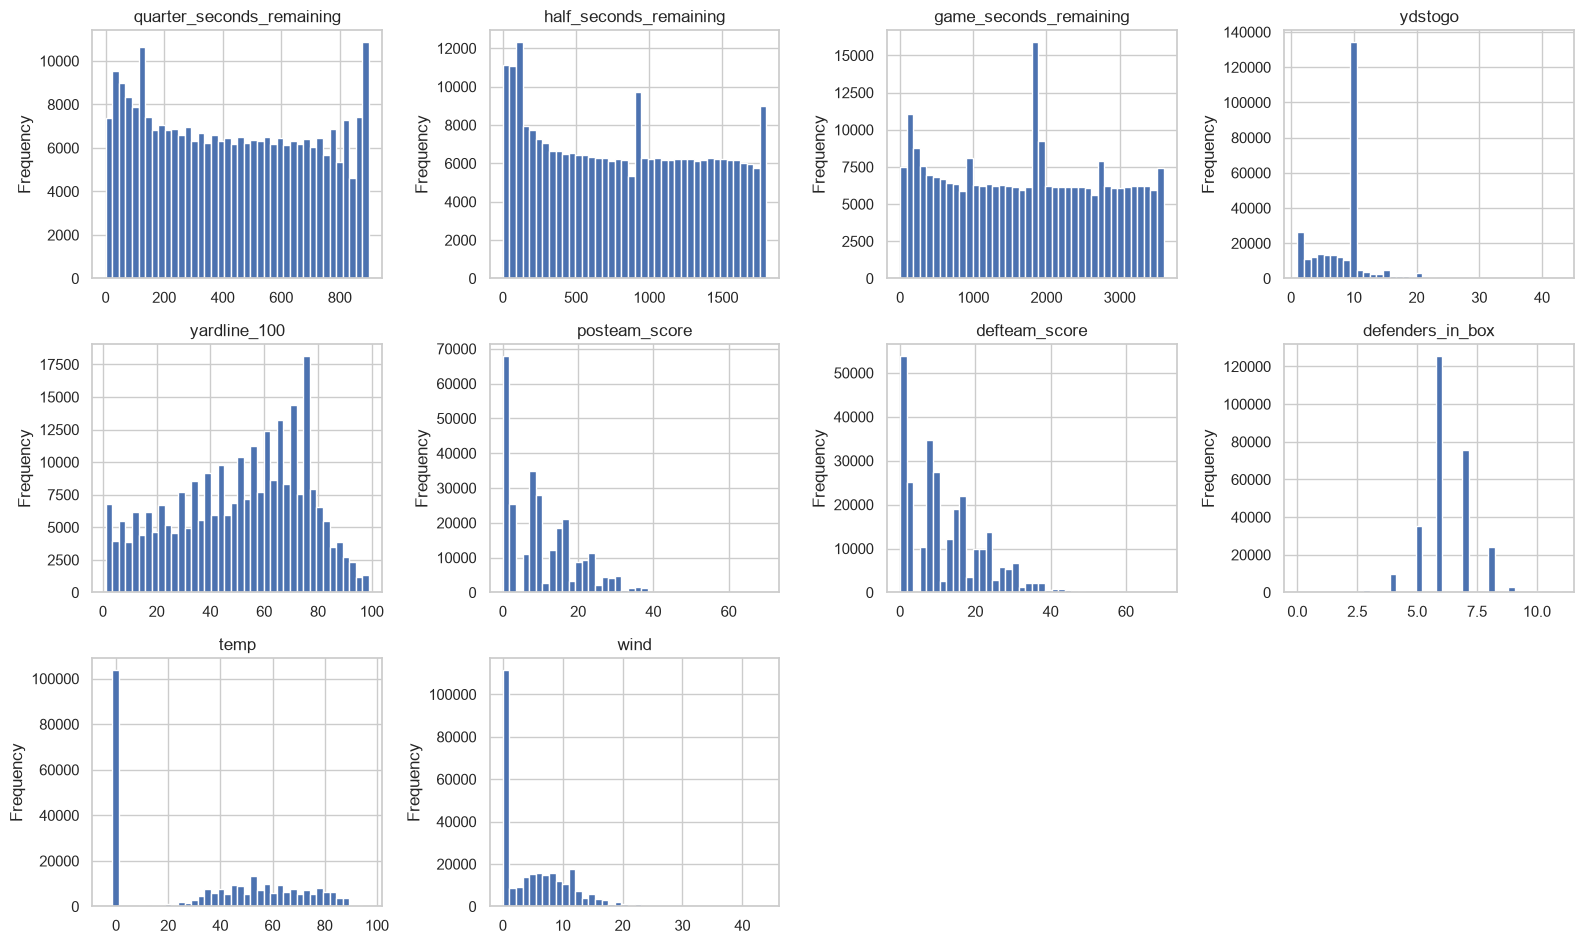

In [9]:
# Distribution of each quantitative feature
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    pbp[col].dropna().plot.hist(ax=axes[i], bins=40, color=PASS_COLOR, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

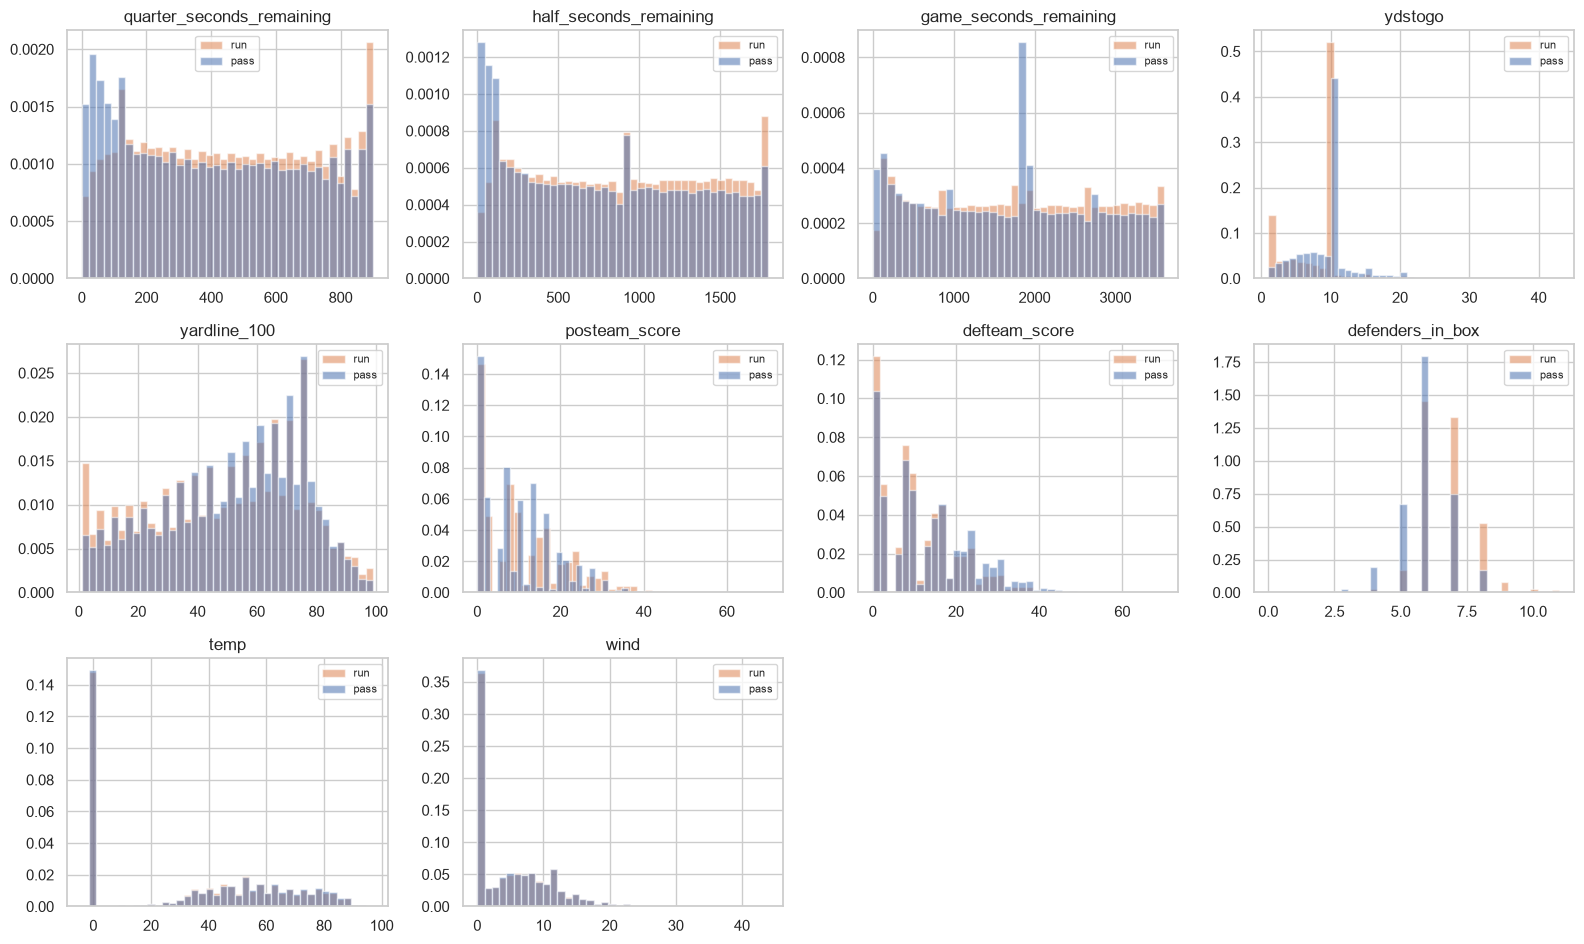

In [10]:
# Distribution of each feature split by play type — where do run and pass separate?
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [("run", RUN_COLOR), ("pass", PASS_COLOR)]:
        vals = pbp.loc[pbp["play_type"] == label, col].dropna()
        axes[i].hist(vals, bins=40, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 4. Categorical Features — Pass Rate by Category

How does pass rate (`P(pass)`) shift across situational categoricals? Large swings mean the feature separates run from pass.

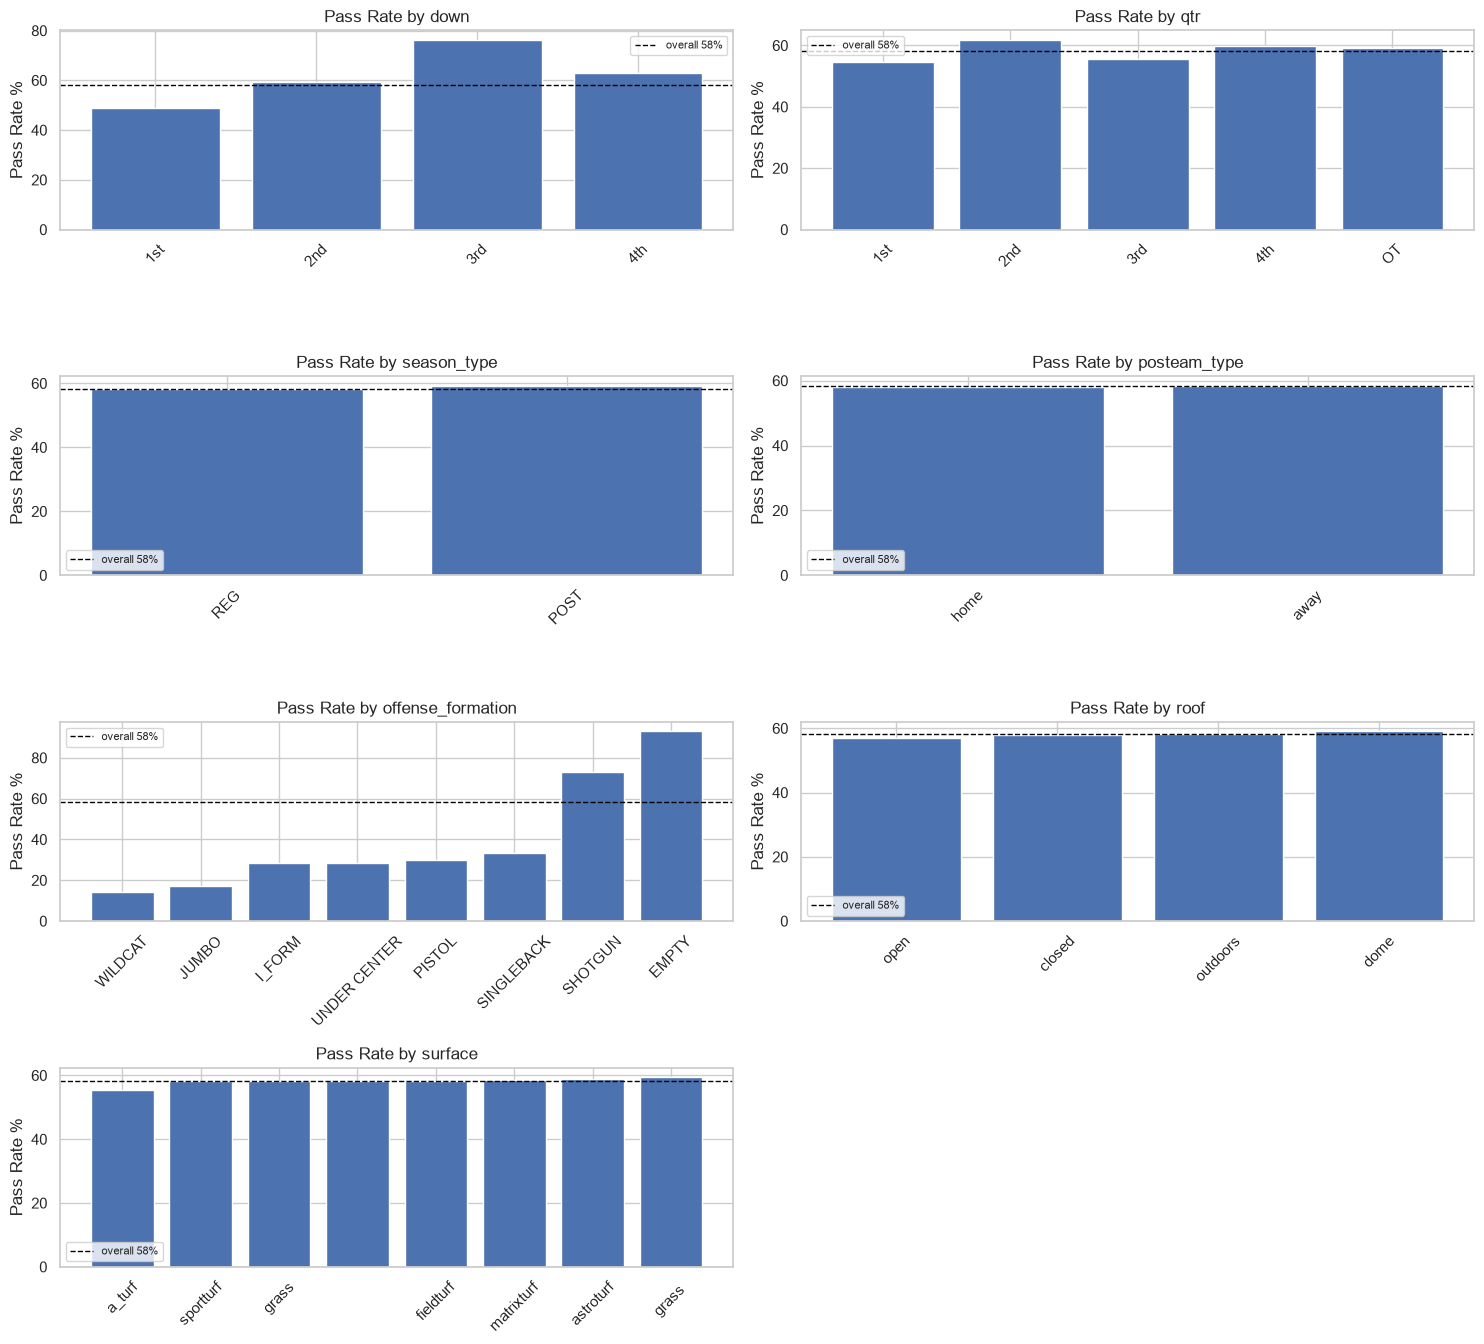

In [11]:
# Pass rate per category, one panel per categorical
cat_cols = [
    "down",
    "qtr",
    "season_type",
    "posteam_type",
    "offense_formation",
    "roof",
    "surface",
]

# Fixed order + display labels for ordinal categoricals; others sort by pass rate.
ORDER = {
    "down": [1, 2, 3, 4],
    "qtr": [1, 2, 3, 4, 5],
}
LABELS = {
    "down": ["1st", "2nd", "3rd", "4th"],
    "qtr": ["1st", "2nd", "3rd", "4th", "OT"],
}

overall = pbp["is_pass"].mean() * 100
n = len(cat_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = (
        pbp.groupby(col)["is_pass"].agg(["mean", "size"])
        .query("size >= 200")  # drop tiny categories that add noise
        .assign(mean=lambda d: d["mean"] * 100)
    )
    if col in ORDER:
        rate = rate.reindex([c for c in ORDER[col] if c in rate.index])
        xlabels = [lab for c, lab in zip(ORDER[col], LABELS[col]) if c in rate.index]
    else:
        rate = rate.sort_values("mean")
        xlabels = rate.index.astype(str)
    ax = axes[i]
    ax.bar(xlabels, rate["mean"], color=PASS_COLOR, edgecolor="white")
    ax.axhline(overall, color="black", linewidth=1, linestyle="--",
               label=f"overall {overall:.0f}%")
    ax.set_title(f"Pass Rate by {col}")
    ax.set_ylabel("Pass Rate %")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

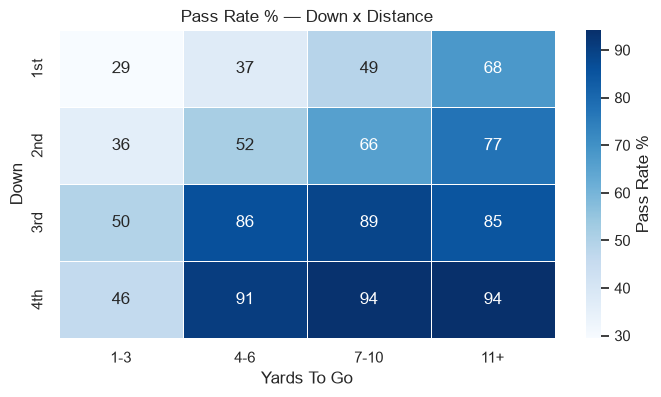

In [12]:
# Pass-rate heatmap: down x distance bucket (the core situational signal)
dist_labels = ["1-3", "4-6", "7-10", "11+"]
pbp["ydstogo_bucket"] = pd.cut(
    pbp["ydstogo"], bins=[0, 3, 6, 10, 100], labels=dist_labels
)

pivot = (pbp.groupby(["down", "ydstogo_bucket"])["is_pass"].mean() * 100).unstack("ydstogo_bucket")

# Fixed down order (rows) and distance order (cols)
pivot = pivot.reindex(index=[1, 2, 3, 4], columns=dist_labels)
pivot.index = ["1st", "2nd", "3rd", "4th"]

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Pass Rate %"})
plt.title("Pass Rate % — Down x Distance")
plt.xlabel("Yards To Go")
plt.ylabel("Down")
plt.show()

Down and yards-to-go drive pass tendency hardest — late downs and long distance push pass rate well above the overall baseline. Formation is nearly deterministic (empty/shotgun lean pass, jumbo/i-form lean run). These situational categoricals plus game state are the backbone of the pre-snap classifier.

## 5. SHOTGUN Deep-Dive — Pass Rate by WR Count

Within `SHOTGUN` plays, does personnel still separate run from pass? Parse the number of wide receivers from `offense_personnel` and check pass rate per WR count — a stacked box with fewer WRs still leaves run on the table even from shotgun.

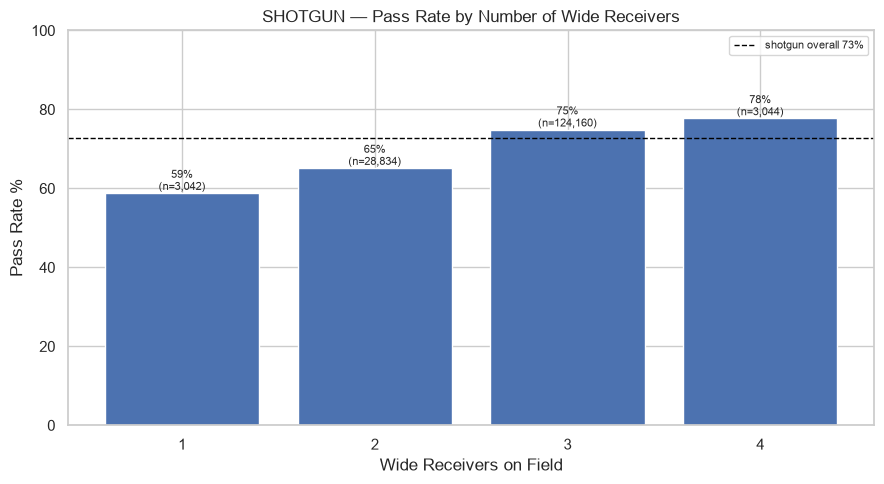

In [13]:
# Pass rate by WR count, SHOTGUN plays only
shotgun = pbp[pbp["offense_formation"] == "SHOTGUN"].copy()

# Parse WR count from the personnel string, e.g. "1 RB, 2 TE, 2 WR" -> 2
shotgun["wr_count"] = (
    shotgun["offense_personnel"].str.extract(r"(\d+)\s+WR", expand=False).astype("float")
)

rate = (
    shotgun.groupby("wr_count")["is_pass"].agg(["mean", "size"])
    .query("size >= 200")  # drop rare personnel groupings
    .assign(mean=lambda d: d["mean"] * 100)
    .sort_index()
)

overall_sg = shotgun["is_pass"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rate.index.astype(int).astype(str), rate["mean"],
              color=PASS_COLOR, edgecolor="white")
ax.axhline(overall_sg, color="black", linewidth=1, linestyle="--",
           label=f"shotgun overall {overall_sg:.0f}%")

# Annotate each bar with pass rate % and play count
for bar, (_, row) in zip(bars, rate.iterrows()):
    ax.annotate(f"{row['mean']:.0f}%\n(n={int(row['size']):,})",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=8)

ax.set_title("SHOTGUN — Pass Rate by Number of Wide Receivers")
ax.set_xlabel("Wide Receivers on Field")
ax.set_ylabel("Pass Rate %")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()